# Distribución Estadística del Rating Elo

Análisis de las propiedades matemáticas y distribucionales del rating Elo clásico,
utilizando el módulo `UnivariateAnalyzer` del paquete `src.analytics`.

**Dataset:** `fide_players_active.parquet`

## Índice

1. [Configuración y Carga de Datos](#1-configuración-y-carga-de-datos)
2. [Estadísticos Descriptivos del Rating Clásico](#2-estadísticos-descriptivos-del-rating-clásico)
3. [Análisis Univariado con UnivariateAnalyzer](#3-análisis-univariado-con-univariateanalyzer)
4. [Reporte de Resumen](#4-reporte-de-resumen)

---

### Próximos análisis a incorporar

- [ ] Tests de bondad de ajuste (D'Agostino-Pearson, Shapiro-Wilk)
- [ ] QQ-Plot contra distribución normal y logística
- [ ] Detección de outliers (IQR, Z-Score)
- [ ] Análisis de barreras psicológicas (2000, 2200, 2400)
- [ ] Histograma de alta resolución (bins unitarios)
- [ ] Percentiles del jugador aficionado (p50, p75, p90, p99 de no titulados)
- [ ] Extensión a rating rápido y blitz


In [95]:
%load_ext autoreload
%autoreload 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats 
from IPython.display import display, HTML


from src.analytics.univariateAnalyzer import UnivariateAnalyzer
from src.analytics.univariateVisualizer import UnivariateVisualizer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configuración y Carga de Datos

In [96]:
df = pd.read_parquet('../data/processed/fide_players_active.parquet')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 437166 entries, 0 to 437165
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   fideid        437166 non-null  string  
 1   name          437166 non-null  string  
 2   country       437166 non-null  category
 3   sex           437166 non-null  category
 4   title         437166 non-null  category
 5   w_title       437166 non-null  category
 6   o_title       437166 non-null  category
 7   rating        219417 non-null  Int64   
 8   rapid_rating  324549 non-null  Int64   
 9   blitz_rating  203133 non-null  Int64   
 10  birthday      437166 non-null  Int64   
 11  flag          437166 non-null  category
 12  es_activo     437166 non-null  bool    
 13  edad          437166 non-null  Int64   
dtypes: Int64(5), bool(1), category(6), string(2)
memory usage: 39.8 MB


## 2. Estadísticos Descriptivos del Rating Clásico

Resumen de los estadísticos básicos de la columna `rating` (Elo clásico) para la población activa.

In [97]:
df['rating'].describe()

count       219417.0
mean     1734.254137
std       223.856323
min           1400.0
25%           1556.0
50%           1700.0
75%           1873.0
max           2823.0
Name: rating, dtype: Float64

## 3. Análisis Univariado con UnivariateAnalyzer

Instanciación del analizador univariado del módulo `src.analytics`.
Calcula métricas de tendencia central, dispersión y forma (curtosis, asimetría).

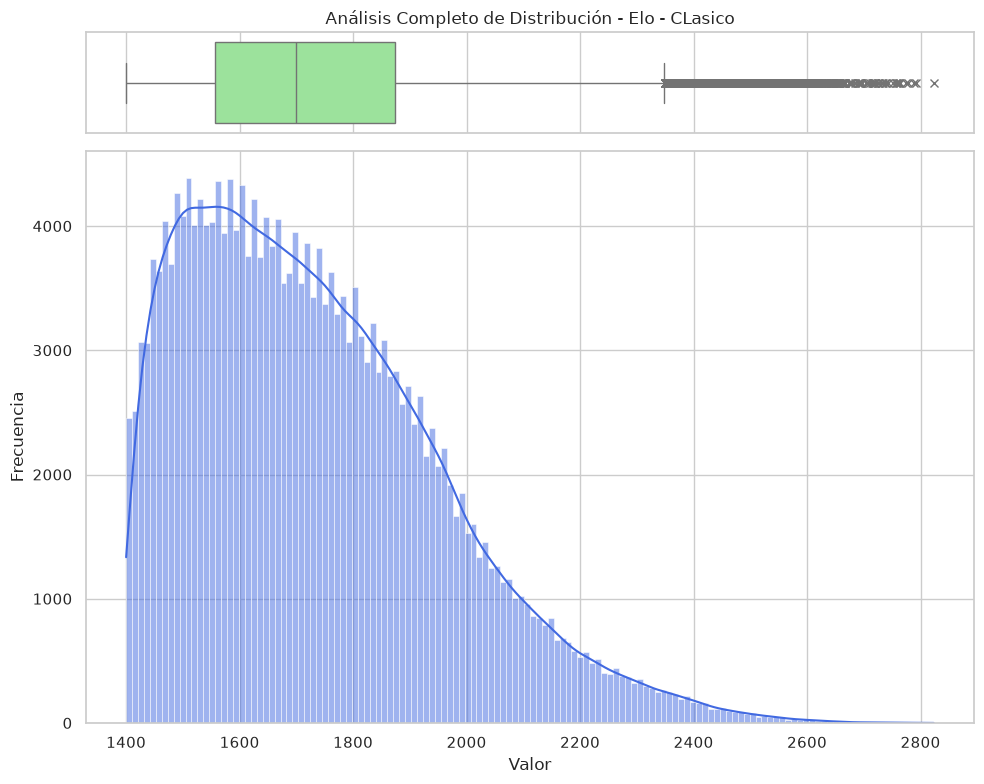

In [98]:
classic = UnivariateAnalyzer(df['rating'])
visualizer = UnivariateVisualizer(df['rating'], title="Elo - CLasico")

visualizer.plot_combined_distribution()

df_medidas_centrales = pd.DataFrame(classic.get_central_tendency(), index=['valores'])
df_medidas_variabilidad = pd.DataFrame(classic.get_central_tendency(), index=['valores'])




## 4. Reporte de Resumen

Generación del reporte consolidado con todas las métricas calculadas.

In [99]:
reporte = classic.generate_summary_report()

df_reporte = classic.generate_summary_report()
df_reporte

Valor
Categoría         Métrica                                               
ESTADO DATOS      Total registros originales                      437166
                  Nulos eliminados                                217749
                  Porcentaje nulos                               49.8092
TENDENCIA CENTRAL Mean                                         1734.2541
                  Median                                          1700.0
                  Mode                                              1572
DISPERSION        Std                                           223.8563
                  Var                                         50111.6531
                  Range                                             1423
                  Iqr                                              317.0
PERCENTILES       25.0                                            1556.0
                  50.0                                            1700.0
                  75.0                                            1873.0
                  90.0                                            2041.0
                  99.0                                            2374.0
FORMA             Asimetria                   Asimetria positiva (0.799)
                  Curtosis                          Leptocurtica (0.376)
OUTLIERS          Limite inferior                                 1080.5
                  Limite superior                                 2348.5
                  Cantidad outliers                                 2777
                  Porcentaje outliers                             1.2656
NORMALIDAD        Estadistico                                 19203.0845
                  P value                                            0.0
                  Es normal                                        False